<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/Worksheet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python Imaging Library(PIL)

## Exercise - 1

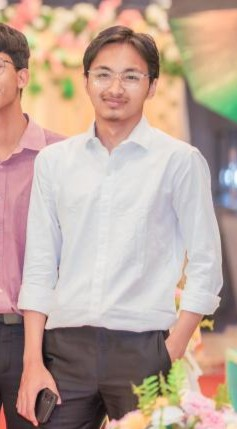

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Read the image
img = Image.open("/content/drive/MyDrive/AI ML/Data/IMG_20230428_231129_23256.jpg")

# Display using Pillow's native display
display(img)

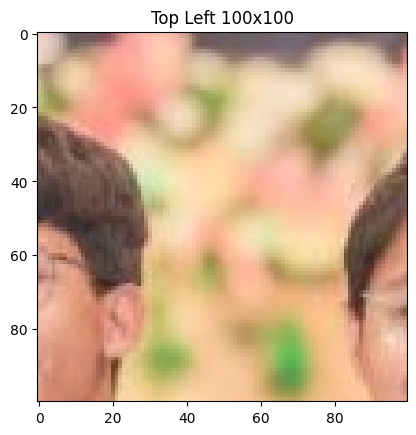

In [3]:
# Convert PIL image to NumPy array
img_array = np.array(img)

# Extract top-left 100x100 pixels using indexing [row_start:row_end, col_start:col_end]
top_left = img_array[0:100, 0:100]

# Display the extracted portion
plt.imshow(top_left, cmap='gray')
plt.title("Top Left 100x100")
plt.show()

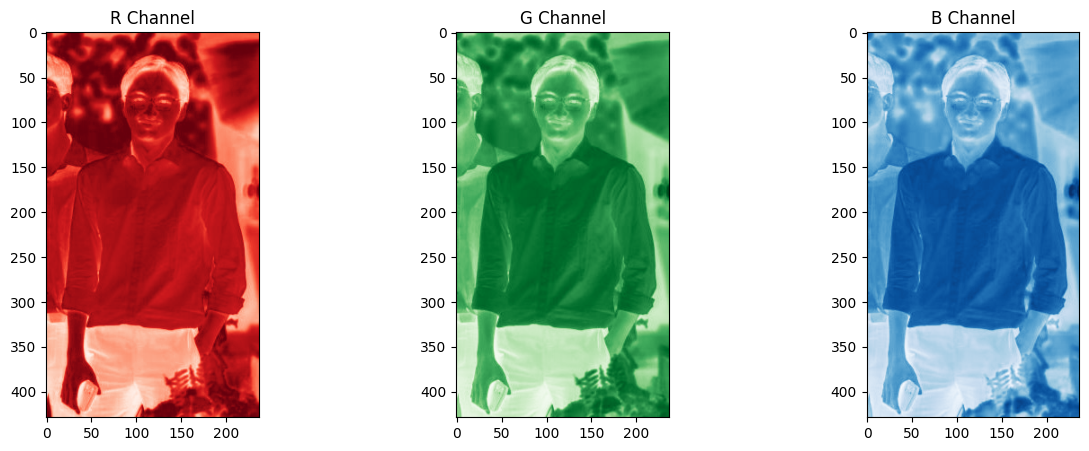

In [5]:
# Load a color image for this task
color_img = Image.open("/content/drive/MyDrive/AI ML/Data/IMG_20230428_231129_23256.jpg")
color_array = np.array(color_img)

# Separate channels
R = color_array[:, :, 0]
G = color_array[:, :, 1]
B = color_array[:, :, 2]

# Display them
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(R, cmap='Reds'); axs[0].set_title('R Channel')
axs[1].imshow(G, cmap='Greens'); axs[1].set_title('G Channel')
axs[2].imshow(B, cmap='Blues'); axs[2].set_title('B Channel')
plt.show()

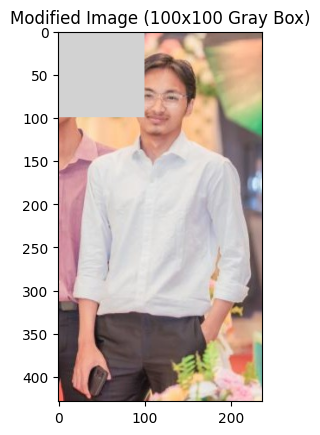

In [6]:
# Create a copy to avoid modifying the original array
modified_img = img_array.copy()

# Set the top-left 100x100 region to 210 (light gray)
modified_img[0:100, 0:100] = 210

# Display the resulting image
plt.imshow(modified_img, cmap='gray')
plt.title("Modified Image (100x100 Gray Box)")
plt.show()

## Exercise - 2

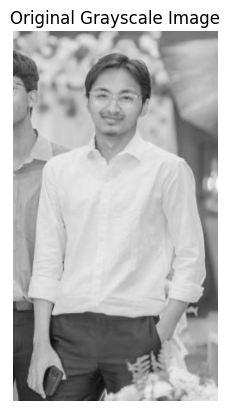

In [7]:
# Load the image
img = Image.open("/content/drive/MyDrive/AI ML/Data/Pi7_IMG_20230428_231129_23256.jpg")

# Convert to NumPy array for subsequent tasks
img_array = np.array(img)

# Display using matplotlib
plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off') # Hide axes for a cleaner look
plt.show()

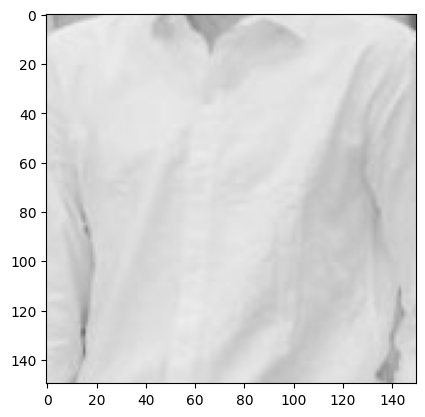

In [14]:
h, w = img_array.shape[:2]

center_h, center_w = h // 2, w // 2

# Now the crop will work regardless of whether the image is Color or Gray
crop_middle = img_array[center_h-75 : center_h+75, center_w-75 : center_w+75]

plt.imshow(crop_middle, cmap='gray' if img_array.ndim == 2 else None)
plt.show()

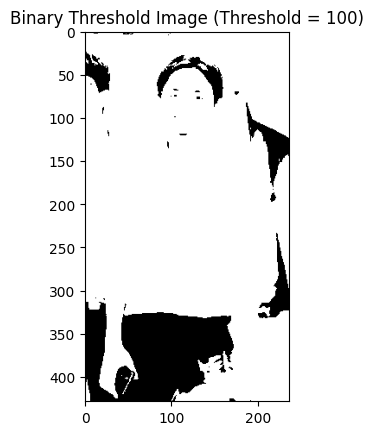

In [10]:
# Create a binary image: 255 (white) if > 100, else 0 (black)
binary_img = np.where(img_array > 100, 255, 0)

plt.imshow(binary_img, cmap='gray')
plt.title("Binary Threshold Image (Threshold = 100)")
plt.show()

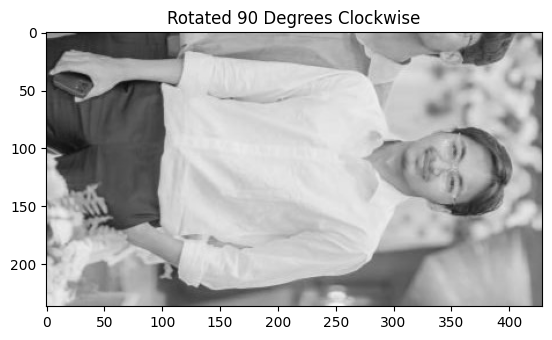

In [12]:
# Using NumPy (Clockwise)
rotated_array = np.rot90(img_array, k=-1)

# Using Pillow
# rotated_pil = img.rotate(-90, expand=True)

plt.imshow(rotated_array, cmap='gray')
plt.title("Rotated 90 Degrees Clockwise")
plt.show()

Verified Shape: (429, 237, 3)


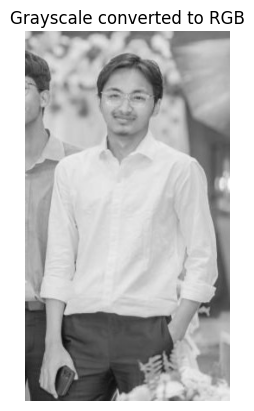

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image and convert to grayscale
img = Image.open("your_image.jpg").convert('L')
img_array = np.array(img, dtype=float)

# Step 1.1: Center the dataset (Subtract Mean)
# We center each column (feature)
mean_adj = np.mean(img_array, axis=0)
standardized_data = img_array - mean_adj

# Step 1.2: Calculate the Covariance Matrix
# Cov = (X^T * X) / (n - 1)
cov_matrix = np.cov(standardized_data, rowvar=False)

print(f"Covariance Matrix Shape: {cov_matrix.shape}")

## Image Compression and Decompression using PCA.

In [19]:
# 1. Load and FORCE conversion to grayscale ('L' mode)
img = Image.open("/content/drive/MyDrive/AI ML/Data/IMG_20230428_231129_23256.jpg").convert('L')
img_array = np.array(img, dtype=float)

# Check the shape - it should be 2D (e.g., (512, 512))
print(f"Array Shape: {img_array.shape}")

# 2. Now Proceed with centering
mean_adj = np.mean(img_array, axis=0)
standardized_data = img_array - mean_adj

# 3. This will now work without the ValueError
cov_matrix = np.cov(standardized_data, rowvar=False)

Array Shape: (429, 237)


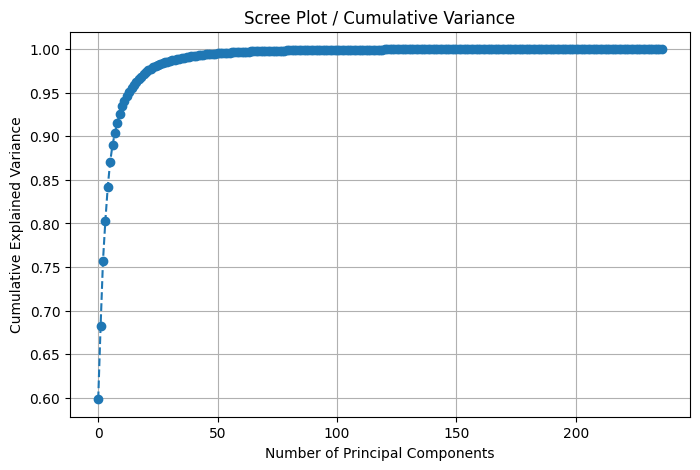

In [21]:
# Compute Eigen Values and Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# Identifying PCs with Cumulative Sum Plot
explained_variance = eigen_values / np.sum(eigen_values)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Variance')
plt.grid()
plt.show()

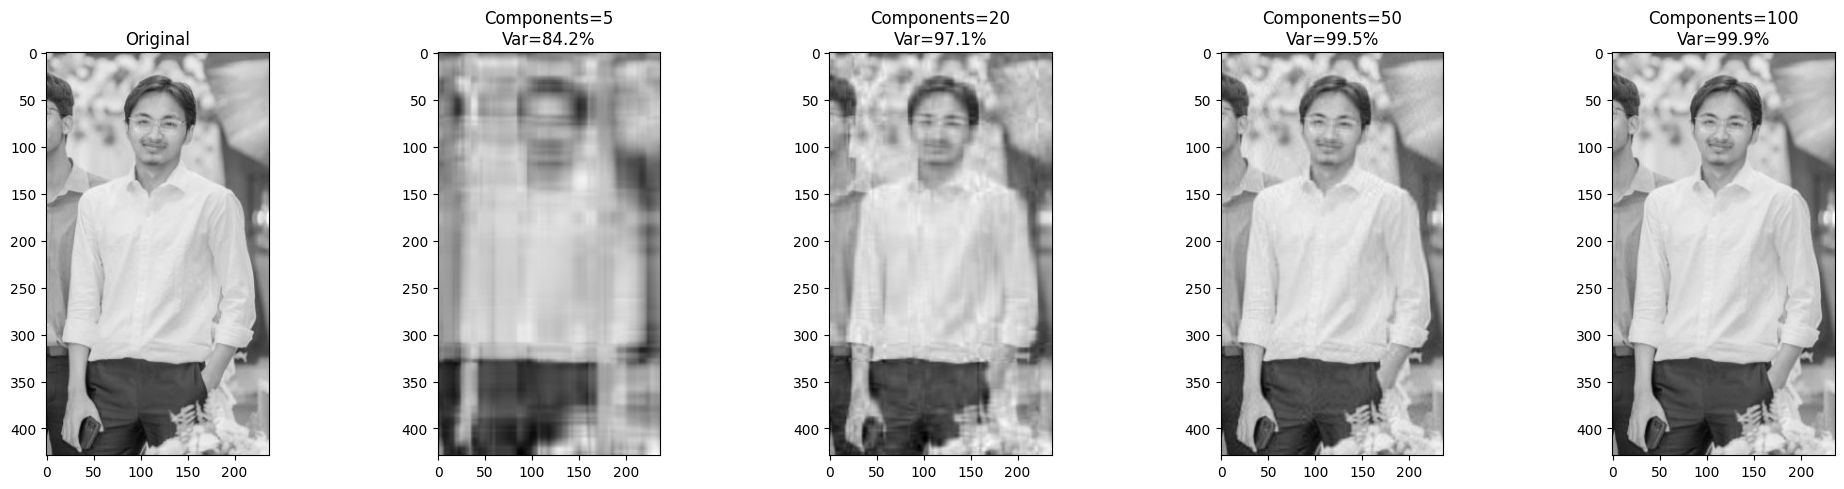

In [23]:
def compress_reconstruct(data, vectors, mean, k):
    # Select top k eigenvectors
    selected_vectors = vectors[:, :k]

    # Transform: Project data into PC space (Compression)
    compressed_data = np.dot(data, selected_vectors)

    # Reconstruct: Project back to original space (Decompression)
    reconstructed_data = np.dot(compressed_data, selected_vectors.T) + mean
    return reconstructed_data

# Experiment: Different k values (e.g., capture 50%, 80%, 95%, 99% variance)
k_values = [5, 20, 50, 100]
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Show original
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")

for i, k in enumerate(k_values):
    recon = compress_reconstruct(standardized_data, eigen_vectors, mean_adj, k)
    var_captured = cumulative_variance[k-1] * 100

    axes[i+1].imshow(recon, cmap='gray')
    axes[i+1].set_title(f"Components={k}\nVar={var_captured:.1f}%")

plt.tight_layout()
plt.show()